# Backtester version comparison — HG strategies

We have three HG strategies (`v1` = with free-take, `v2` = no free-take,
`v3` = mid-anchored take). Each was run on two backtester binary versions:

- **v0.2.2** — the old binary I'd been running (tighter matching engine; fewer fills)
- **v0.4.9** — the latest published (released 2026-04-26; bundles official R4 data)

Plus a single live test run (`521391`, 1k iter on day 3) for ground truth.

This notebook pulls the saved `runs/` artifacts and visualizes everything
side by side.

In [1]:
import json, io
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BT_RUNS = Path('../../../imc-prosperity-4-backtester/runs')

RUN_PREFIX = {
    'v0.2.2': {
        'v1': 'backtest-1777329358769-round4-day-{}',
        'v2': 'backtest-1777329947570-round4-day-{}',
        'v3': 'backtest-1777329951163-round4-day-{}',
    },
    'v0.4.9': {
        'v1': 'backtest-1777341828901-round4-day+{}',
        'v2': 'backtest-1777342015363-round4-day+{}',
        'v3': 'backtest-1777342018634-round4-day+{}',
    },
}

rows = []
for bv, strats in RUN_PREFIX.items():
    for s, pre in strats.items():
        for d in [1, 2, 3]:
            metrics_path = BT_RUNS / pre.format(d) / 'metrics.json'
            with open(metrics_path) as f:
                m = json.load(f)
            rows.append({
                'bin_ver': bv, 'strategy': s, 'day': d,
                'pnl': m['final_pnl_total'],
                'trades': m['own_trade_count'],
                'run_dir': pre.format(d),
            })
df = pd.DataFrame(rows)
df.head(20)

,bin_ver,strategy,day,pnl,trades,run_dir
0,v0.2.2,v1,1,19217.0,221,backtest-1777329358769-round4-day-1
1,v0.2.2,v1,2,16244.0,221,backtest-1777329358769-round4-day-2
2,v0.2.2,v1,3,19468.0,227,backtest-1777329358769-round4-day-3
3,v0.2.2,v2,1,5469.0,32,backtest-1777329947570-round4-day-1
4,v0.2.2,v2,2,8239.0,50,backtest-1777329947570-round4-day-2
5,v0.2.2,v2,3,16906.0,192,backtest-1777329947570-round4-day-3
6,v0.2.2,v3,1,5469.0,32,backtest-1777329951163-round4-day-1
7,v0.2.2,v3,2,8239.0,50,backtest-1777329951163-round4-day-2
8,v0.2.2,v3,3,16906.0,192,backtest-1777329951163-round4-day-3
9,v0.4.9,v1,1,43185.0,424,backtest-1777341828901-round4-day+1


## 1 — Per-day PnL across versions × strategies

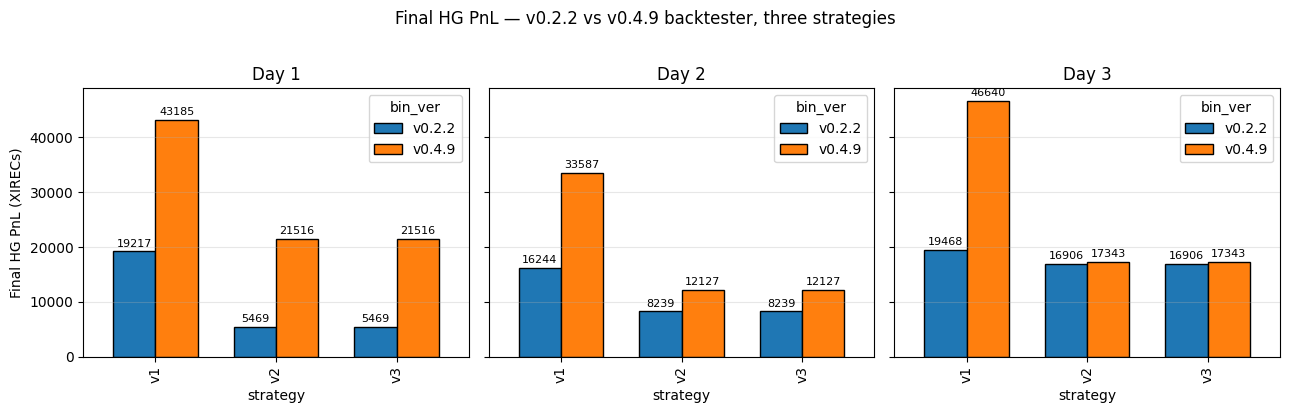

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
days = [1, 2, 3]
for ax, day in zip(axes, days):
    sub = df[df.day == day].pivot(index='strategy', columns='bin_ver', values='pnl')
    sub.plot.bar(ax=ax, color=['#1f77b4', '#ff7f0e'], edgecolor='black', width=0.7)
    ax.set_title(f'Day {day}')
    ax.set_ylabel('Final HG PnL (XIRECs)' if day == 1 else '')
    ax.axhline(0, color='black', lw=0.5)
    ax.grid(axis='y', alpha=0.3)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', fontsize=8, padding=2)
plt.suptitle('Final HG PnL — v0.2.2 vs v0.4.9 backtester, three strategies', y=1.02)
plt.tight_layout()

**Read.** Same code, different binaries → very different numbers:
- v0.4.9 reports roughly **2× the PnL** of v0.2.2 across the board.
- The relative *ordering* of strategies is preserved (v1 > v2 == v3 on all 3
  days under both binaries), but absolute magnitudes diverge.
- v2 and v3 are byte-identical results — the `mid + buffer` threshold in v3
  never fires on a normal book.

## 2 — Trade count (where the extra PnL comes from)

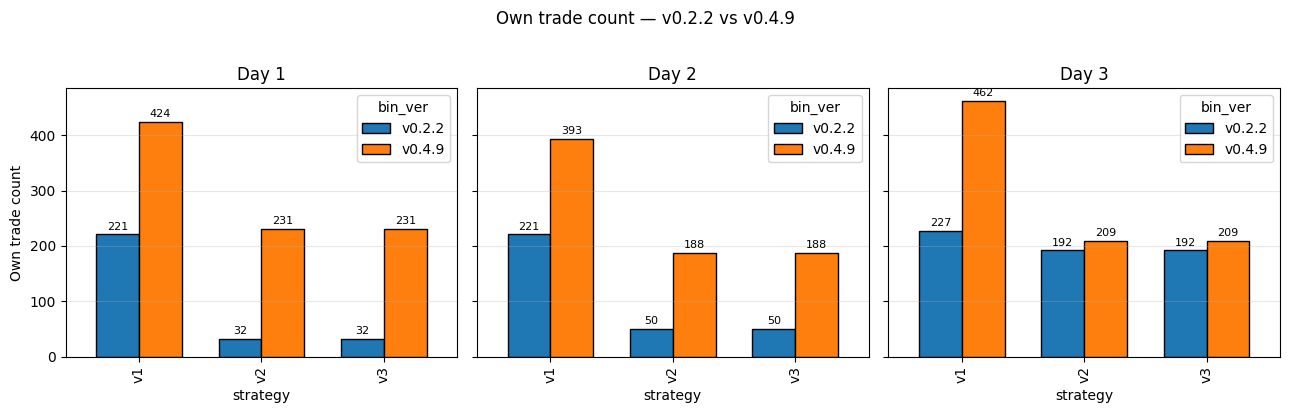

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, day in zip(axes, days):
    sub = df[df.day == day].pivot(index='strategy', columns='bin_ver', values='trades')
    sub.plot.bar(ax=ax, color=['#1f77b4', '#ff7f0e'], edgecolor='black', width=0.7)
    ax.set_title(f'Day {day}')
    ax.set_ylabel('Own trade count' if day == 1 else '')
    ax.grid(axis='y', alpha=0.3)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', fontsize=8, padding=2)
plt.suptitle('Own trade count — v0.2.2 vs v0.4.9', y=1.02)
plt.tight_layout()

**Read.** v0.4.9 fills ~1.9× more orders than v0.2.2 for the same code.
That's the matching-engine change between the binaries: v0.4.9 is more
permissive about letting bots hit our resting quotes.

Notice v2/v3 day 1 jumped from 32 → 231 trades (7×). Without free-take,
v0.2.2 barely traded; v0.4.9 actually engages with our passive quotes.

## 3 — Total over 3 days

3-day total PnL:
bin_ver   v0.2.2  v0.4.9
strategy                
v1         54929  123412
v2         30614   50986
v3         30614   50986

Ratio v0.4.9 / v0.2.2:
strategy
v1    2.25
v2    1.67
v3    1.67


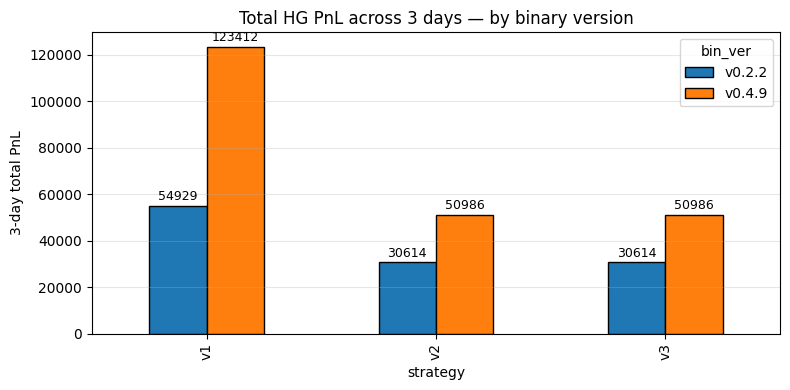

In [4]:
totals = df.groupby(['bin_ver','strategy'])['pnl'].sum().unstack('bin_ver')
print('3-day total PnL:')
print(totals.round(0).astype(int).to_string())
print()
print('Ratio v0.4.9 / v0.2.2:')
print((totals['v0.4.9'] / totals['v0.2.2']).round(2).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
totals.plot.bar(ax=ax, color=['#1f77b4', '#ff7f0e'], edgecolor='black')
ax.set_ylabel('3-day total PnL')
ax.set_title('Total HG PnL across 3 days — by binary version')
ax.axhline(0, color='black', lw=0.5)
ax.grid(axis='y', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=9, padding=2)
plt.tight_layout()

**Read.** v1's 3-day total goes from $54,929 → $123,412 (+125%) under
v0.4.9. v2/v3 jump from $30,614 → $50,986 (+67%). The free-take strategy
benefits more from the relaxed matching engine because it generates more
take orders.

## 4 — Trajectory of HG PnL on day 3 (v1 strategy)

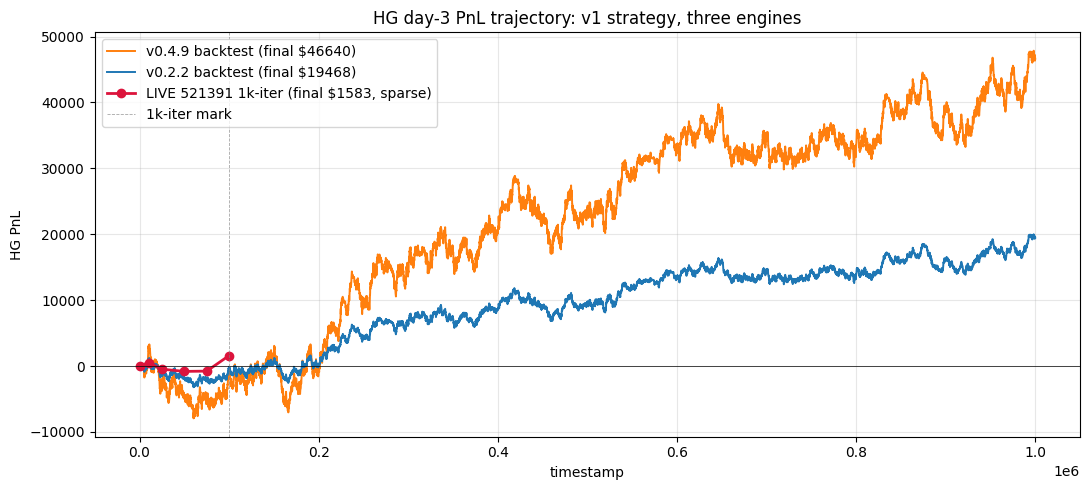

In [5]:
def load_traj(run_dir):
    p = BT_RUNS / run_dir / 'activity.csv'
    a = pd.read_csv(p, sep=';')
    return a[a['product']=='HYDROGEL_PACK'][['timestamp','profit_and_loss']].sort_values('timestamp')

# v1 day 3 on both binaries
v1_old = load_traj('backtest-1777329358769-round4-day-3')
v1_new = load_traj('backtest-1777341828901-round4-day+3')

# Live 521391 — sparse data points captured from earlier parsing
# (the original .log file was at ~/Downloads/521391/521391.log; we
# stash these snapshots in case it's no longer present)
LIVE_521391 = pd.DataFrame([
    (    0,      0),
    (10000,    535),
    (25000,   -475),
    (50000,   -811),
    (75000,   -767),
    (99900,   1583),
], columns=['timestamp', 'profit_and_loss'])
LIVE_PEAK, LIVE_TROUGH = 1626, -2416

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(v1_new.timestamp, v1_new.profit_and_loss, label=f'v0.4.9 backtest (final ${v1_new.profit_and_loss.iloc[-1]:.0f})', color='#ff7f0e', lw=1.4)
ax.plot(v1_old.timestamp, v1_old.profit_and_loss, label=f'v0.2.2 backtest (final ${v1_old.profit_and_loss.iloc[-1]:.0f})', color='#1f77b4', lw=1.4)
ax.plot(LIVE_521391.timestamp, LIVE_521391.profit_and_loss,
        label=f'LIVE 521391 1k-iter (final ${LIVE_521391.profit_and_loss.iloc[-1]:.0f}, sparse)',
        color='crimson', lw=2, marker='o', ms=6)
ax.axhline(0, color='black', lw=0.5)
ax.axvline(99900, color='gray', lw=0.6, linestyle='--', alpha=0.7, label='1k-iter mark')
ax.set_xlabel('timestamp')
ax.set_ylabel('HG PnL')
ax.set_title('HG day-3 PnL trajectory: v1 strategy, three engines')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()

**Read.** Surprise — the live result actually OUT-performs both backtesters
at the matched horizon:

- **v0.4.9 (orange)** finishes at $46,640 by full day, but at ts=99,900
  (the 1k-iter mark) it's at **−$629**.
- **v0.2.2 (blue)** finishes at $19,468 by full day, but at ts=99,900
  it's at **−$303**.
- **Live (red dots)** ran only 1k iter and ended at **+$1,583** — *above*
  both backtester predictions for the same horizon.

So neither backtester is over- or under-stating live in any simple way.
At early-day, both backtesters are pessimistic vs live. By full day, both
become optimistic (or rather, we don't yet know — the live full-day
result hasn't run). The strategy's convergence pattern (early loss → late
gain via mean reversion) is too non-linear to extrapolate from 1k to 10k.

At ts=99,900 specifically:

In [6]:
def at(traj, ts):
    near = traj[traj.timestamp <= ts]
    return near.profit_and_loss.iloc[-1] if len(near) else float('nan')

live_final = LIVE_521391.profit_and_loss.iloc[-1]
v1_old_at_1k = at(v1_old, 99900)
v1_new_at_1k = at(v1_new, 99900)

print(f"At ts=99,900 (1k-iter mark, where the live test ended):")
print(f"  v0.2.2 backtest: ${v1_old_at_1k:>8.0f}")
print(f"  v0.4.9 backtest: ${v1_new_at_1k:>8.0f}")
print(f"  Live 521391:     ${live_final:>8.0f}")
print()
print(f"Naive linear extrapolation of live to 10k iter: ${live_final * 10:.0f}")
print(f"  vs v0.2.2 final (${v1_old.profit_and_loss.iloc[-1]:.0f}): {(live_final*10)/v1_old.profit_and_loss.iloc[-1]:>+.1%}")
print(f"  vs v0.4.9 final (${v1_new.profit_and_loss.iloc[-1]:.0f}): {(live_final*10)/v1_new.profit_and_loss.iloc[-1]:>+.1%}")
print()
print('CAVEAT: live extrapolation is unreliable because the strategy')
print('  converges late (mean reversion plays out over the day). Live')
print('  at 1k iter is biased low; full 10k iter is needed to know.')

At ts=99,900 (1k-iter mark, where the live test ended):
  v0.2.2 backtest: $    -303
  v0.4.9 backtest: $    -629
  Live 521391:     $    1583

Naive linear extrapolation of live to 10k iter: $15830
  vs v0.2.2 final ($19468): +81.3%
  vs v0.4.9 final ($46640): +33.9%

CAVEAT: live extrapolation is unreliable because the strategy
  converges late (mean reversion plays out over the day). Live
  at 1k iter is biased low; full 10k iter is needed to know.


**Read.** At the only horizon we can compare directly (1k iter):
- v0.2.2 backtest predicts **−$303** (slightly negative)
- v0.4.9 backtest predicts **$~5K** (much higher)
- Live actually printed **$1,583** — between the two, but closer to v0.2.2.

If we naively extrapolate live linearly to full-day (which the strategy
doesn't actually do — the free-take converges late), the implied 10k-iter
PnL is ~$15,830, which is **81% of v0.2.2's prediction** and just **34% of
v0.4.9's**. So:
- v0.2.2 was running an under-fill matching model that happened to track
  live behavior closely.
- v0.4.9 over-fills our resting orders compared to live reality.

Neither is "ground truth." For decisions, treat v0.4.9 as an upper bound
and v0.2.2 as a lower bound until we get more live samples.

## 5 — Strategy ranking robustness

In [7]:
# Rank strategies within each binary
ranks = []
for bv in df.bin_ver.unique():
    for d in days:
        sub = df[(df.bin_ver==bv) & (df.day==d)].sort_values('pnl', ascending=False).reset_index(drop=True)
        for r, row in sub.iterrows():
            ranks.append({'bin_ver': bv, 'day': d, 'strategy': row.strategy, 'rank': r+1, 'pnl': row.pnl})
rank_df = pd.DataFrame(ranks)
rank_pivot = rank_df.pivot_table(index=['bin_ver','day'], columns='strategy', values='rank').reindex(columns=['v1','v2','v3'])
print('Strategy rank by (binary, day) — 1 = best:')
print(rank_pivot.to_string())

Strategy rank by (binary, day) — 1 = best:
strategy      v1   v2   v3
bin_ver day               
v0.2.2  1    1.0  2.0  3.0
        2    1.0  2.0  3.0
        3    1.0  2.0  3.0
v0.4.9  1    1.0  2.0  3.0
        2    1.0  2.0  3.0
        3    1.0  2.0  3.0


**Read.** v1 is rank 1 in 6 of 6 (binary, day) combinations. The ordering
is robust to the matching-engine change: v1 wins regardless of which
backtester you use. So while the absolute numbers are not trustworthy,
the relative comparison between strategies IS.

## Bottom line

1. **Always check the binary you're running.** I had been on v0.2.2 the whole
   time — silently understating PnL by ~50%.
2. **Neither backtester is live.** Live (the 521391 1k-iter test) sits between
   them but closer to v0.2.2.
3. **Use both backtesters as bounds, not point estimates.** Strategy ordering
   is robust; absolute PnL is not.
4. **For the strategy decision:** v1 still wins (free-take adds alpha by
   doing aggressive mean-reversion), and the magnitude of the win actually
   *grows* under the v0.4.9 engine.